# New York Knicks Pick-and-Roll Defense — 2015-16 Season

A pick-and-roll (PnR) is the most common action in the NBA. How a defense handles it determines a lot about whether they give up easy buckets.

This notebook uses raw SportVU player tracking data (25 frames/sec) to:
1. **Detect** when a pick-and-roll screen is set
2. **Classify** what defensive coverage the Knicks used
3. **Measure** what outcomes each coverage produced

### The 5 coverage types we classify

| Coverage | What happens |
|---|---|
| **Drop** | Big stays below the screen near the paint; guard goes over |
| **Hedge** | Big jumps out briefly above the screen to slow the ball handler, then recovers |
| **Blitz** | Both defenders converge on the ball handler above the screen |
| **Ice** | Guard funnels the ball handler toward the sideline before the screen; big drops |
| **Catch Hedge** | Big meets the ball handler at screen level without going past it |

**Data:** 20 NYK games, 2015-16 season

In [20]:
import json, os, glob, subprocess, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/willhanley/Desktop/spacing/nba-movement-data/data'
NYK_ID   = 1610612752   # New York Knicks team ID
FPS      = 25

# Pick first 20 NYK game archives
NYK_ARCHIVES = sorted(glob.glob(os.path.join(DATA_DIR, '*.7z')))
NYK_ARCHIVES = [f for f in NYK_ARCHIVES if 'NYK' in os.path.basename(f)][:20]
print(f'Games to process: {len(NYK_ARCHIVES)}')
for f in NYK_ARCHIVES:
    print(' ', os.path.basename(f))

Games to process: 20
  01.01.2016.NYK.at.CHI.7z
  01.03.2016.ATL.at.NYK.7z
  01.05.2016.NYK.at.ATL.7z
  01.06.2016.NYK.at.MIA.7z
  01.08.2016.NYK.at.SAS.7z
  01.10.2016.MIL.at.NYK.7z
  01.12.2016.BOS.at.NYK.7z
  01.13.2016.NYK.at.BKN.7z
  01.18.2016.PHI.at.NYK.7z
  01.20.2016.UTA.at.NYK.7z
  01.22.2016.LAC.at.NYK.7z
  01.23.2016.NYK.at.CHA.7z
  10.28.2015.NYK.at.MIL.7z
  10.29.2015.ATL.at.NYK.7z
  10.31.2015.NYK.at.WAS.7z
  11.02.2015.SAS.at.NYK.7z
  11.04.2015.NYK.at.CLE.7z
  11.06.2015.MIL.at.NYK.7z
  11.08.2015.LAL.at.NYK.7z
  11.10.2015.NYK.at.TOR.7z


## Step 1 — Core Functions

Three steps happen on every game:
1. **Compute velocities** — differentiate positions to get speed at each frame
2. **Build defensive matchups** — who is guarding whom at the start of each possession (Hungarian algorithm)
3. **Detect screens** — find frames where an offensive player is stationary and a defender is being blocked off them

In [21]:
# ── Velocity ──
def compute_velocities(df):
    players = df[~df['is_ball']].copy()
    players = players.sort_values(
        ['event_id','player_id','quarter','game_clock'],
        ascending=[True,True,True,False]
    ).reset_index(drop=True)
    grp = players.groupby(['event_id','player_id'])
    players['dx'] = grp['x'].diff()
    players['dy'] = grp['y'].diff()
    players['speed'] = np.sqrt(players['dx']**2 + players['dy']**2) * FPS
    players.loc[players['speed'] > 30, 'speed'] = np.nan
    players['speed_smooth'] = (
        players.groupby(['event_id','player_id'])['speed']
        .transform(lambda s: s.rolling(5, min_periods=1, center=True).mean())
    )
    return players


# ── Defensive Assignment (Hungarian algorithm) ──
def build_defensive_assignments(df, players_df, home_id, vis_id):
    """
    At the start of each possession, assign each defender to the offensive
    player they are most likely guarding. Uses the Hungarian algorithm on a
    cost matrix of distance + positional mismatch (bigs on bigs, guards on guards).
    """
    def basket_dist(x, y, bx):
        return np.sqrt((x - bx)**2 + (y - 25)**2)

    all_assignments = {}
    for event_id, event_df in df.groupby('event_id'):
        if event_df['offensive_team_id'].isna().all():
            continue
        off_team = event_df['offensive_team_id'].dropna().iloc[0]
        def_team = home_id if off_team == vis_id else vis_id

        ball_x = event_df[event_df['is_ball']]['x'].mean()
        bask_x = 5.25 if (ball_x < 47 or pd.isna(ball_x)) else 88.75

        # Use early shot-clock frames to get settled positions
        early = event_df[event_df['shot_clock'].between(14, 20)]
        if early.empty:
            mc = event_df['game_clock'].max()
            early = event_df[event_df['game_clock'].between(mc - 4, mc - 1)]
        if early.empty:
            continue

        avg_pos = (
            early[early['player_id'] != -1]
            .groupby(['team_id','player_id'])[['x','y']].mean().reset_index()
        )
        offs = avg_pos[avg_pos['team_id'] == off_team]
        defs = avg_pos[avg_pos['team_id'] == def_team]
        if len(offs) < 2 or len(defs) < 2:
            continue

        off_ids, def_ids = offs['player_id'].values, defs['player_id'].values
        off_pos, def_pos = offs[['x','y']].values, defs[['x','y']].values
        off_bd = np.array([basket_dist(x, y, bask_x) for x, y in off_pos])
        def_bd = np.array([basket_dist(x, y, bask_x) for x, y in def_pos])

        cost = np.zeros((len(def_ids), len(off_ids)))
        for di, (dx, dy) in enumerate(def_pos):
            for oi, (ox, oy) in enumerate(off_pos):
                dist = np.sqrt((dx-ox)**2 + (dy-oy)**2)
                mismatch = abs(def_bd[di] - off_bd[oi])
                cost[di, oi] = dist + 0.4 * mismatch

        di_arr, oi_arr = linear_sum_assignment(cost)
        event_assign = {}
        for di, oi in zip(di_arr, oi_arr):
            if cost[di, oi] < 20:
                event_assign[def_ids[di]] = off_ids[oi]
        if len(event_assign) >= 2:
            all_assignments[event_id] = event_assign

    return all_assignments


# ── Screen Detection ──
SCREEN_SPEED_THRESH = 2.5   # ft/s — below this = stationary
SCREEN_MIN_FRAMES   = 10    # must be stationary for >= 10 frames
BH_MAX_DIST         = 15    # ball handler must be within 15 ft of screen
SCREEN_SET_DIST     = 6     # a defender must be within 6 ft of the screen location

def detect_screens(df, players_df, assignments, def_team_id):
    """
    Find frames where:
      - An offensive player is stationary (potential screener)
      - A defender of def_team_id is within 6 ft (being screened)
      - The ball handler is within 15 ft (using the screen)
    Returns one row per unique PnR action.
    """
    screens = []

    for event_id, event_players in players_df.groupby('event_id'):
        event_df = df[df['event_id'] == event_id].copy()
        if event_df['offensive_team_id'].isna().all():
            continue
        off_team = event_df['offensive_team_id'].dropna().iloc[0]
        if off_team == def_team_id:
            continue  # NYK is offense here — skip

        base_assign = assignments.get(event_id, {})
        if not base_assign:
            continue

        off_players = event_players[
            (event_players['team_id'] == off_team) & (event_players['player_id'] != -1)
        ].copy()
        off_players['is_stationary'] = off_players['speed_smooth'] < SCREEN_SPEED_THRESH

        for pid, pdata in off_players.groupby('player_id'):
            pdata = pdata.sort_values('game_clock', ascending=False).reset_index(drop=True)
            pdata['run_id'] = (pdata['is_stationary'] != pdata['is_stationary'].shift()).cumsum()
            for _, run in pdata.groupby('run_id'):
                if not run['is_stationary'].iloc[0] or len(run) < SCREEN_MIN_FRAMES:
                    continue

                row0 = run.iloc[0]
                scr_clock, scr_q = row0['game_clock'], row0['quarter']
                scr_x, scr_y = row0['x'], row0['y']

                # Skip screens near basket (post actions, not PnR)
                bask_x = 5.25 if scr_x < 47 else 88.75
                if abs(scr_x - bask_x) < 15:
                    continue

                moment = event_df[
                    (event_df['quarter'] == scr_q) &
                    (np.abs(event_df['game_clock'] - scr_clock) < 0.05)
                ]
                if moment.empty:
                    continue

                defenders = moment[
                    (moment['team_id'] == def_team_id) & (~moment['is_ball']) & (moment['player_id'] != -1)
                ]
                ball_rows = moment[moment['is_ball']]
                if defenders.empty or ball_rows.empty:
                    continue

                ball_row = ball_rows.iloc[0]

                # Find ball handler (closest offensive player to ball)
                offense = moment[
                    (moment['team_id'] == off_team) & (~moment['is_ball']) & (moment['player_id'] != -1)
                ]
                if offense.empty:
                    continue
                dists = np.sqrt((offense['x'] - ball_row['x'])**2 + (offense['y'] - ball_row['y'])**2)
                bh_id = offense.iloc[dists.argmin()]['player_id']
                if bh_id == pid:
                    continue

                bh_row = moment[moment['player_id'] == bh_id]
                if bh_row.empty:
                    continue
                bh_dist = np.sqrt((bh_row.iloc[0]['x'] - scr_x)**2 + (bh_row.iloc[0]['y'] - scr_y)**2)
                if bh_dist > BH_MAX_DIST:
                    continue

                # A defender must be near the screen
                def_dists = np.sqrt((defenders['x'] - scr_x)**2 + (defenders['y'] - scr_y)**2)
                if def_dists.min() > SCREEN_SET_DIST:
                    continue

                screener_def = next((d for d, o in base_assign.items() if o == pid), None)
                bh_def       = next((d for d, o in base_assign.items() if o == bh_id), None)
                if screener_def is None or bh_def is None or screener_def == bh_def:
                    continue

                screens.append({
                    'event_id': event_id, 'quarter': scr_q, 'game_clock': scr_clock,
                    'screener_id': pid, 'bh_id': bh_id,
                    'screener_def_id': screener_def, 'bh_def_id': bh_def,
                    'off_team': off_team, 'def_team': def_team_id,
                    'screen_x': scr_x, 'screen_y': scr_y,
                })

    if not screens:
        return pd.DataFrame()

    result = pd.DataFrame(screens)
    # Dedup: same screener+BH within a 5-second window = same physical screen
    result = result.sort_values('game_clock', ascending=False)
    result['_bucket'] = (result['game_clock'] // 5).astype(int)
    result = (result
        .drop_duplicates(['event_id','quarter','screener_id','bh_id'])
        .drop_duplicates(['quarter','screener_id','bh_id','_bucket'])
        .drop(columns='_bucket')
        .reset_index(drop=True))
    return result

print('Core functions defined.')

Core functions defined.


In [22]:
# ── Feature Extraction ──
def extract_features(screen, df):
    """
    For each detected screen, look at the 3 seconds after to measure what the
    Knicks defenders did. The key question: did the big come out above the screen?
    """
    eid   = screen['event_id']
    q     = screen['quarter']
    t0    = screen['game_clock']
    bh_id = screen['bh_id']
    big_id = screen['screener_def_id']
    grd_id = screen['bh_def_id']
    scr_id = screen['screener_id']
    scr_x, scr_y = screen['screen_x'], screen['screen_y']
    basket_x = 5.25 if scr_x < 47 else 88.75

    post = df[
        (df['event_id'] == eid) & (df['quarter'] == q) &
        (df['game_clock'] <= t0) & (df['game_clock'] >= t0 - 3.0)
    ].copy()
    pre = df[
        (df['event_id'] == eid) & (df['quarter'] == q) &
        (df['game_clock'] > t0) & (df['game_clock'] <= t0 + 1.5)
    ].copy()

    if post.empty:
        return None

    pids = [p for p in [bh_id, scr_id, big_id, grd_id] if p != -1]
    wide = post[post['player_id'].isin(pids)].pivot_table(
        index='game_clock', columns='player_id', values=['x','y']
    ).dropna()
    if len(wide) < 5:
        return None

    def pos(pid):
        try: return wide['x'][pid].values, wide['y'][pid].values
        except KeyError: return None, None

    bh_x,  bh_y  = pos(bh_id)
    big_x, big_y = pos(big_id)
    grd_x, grd_y = pos(grd_id)
    sc_x,  sc_y  = pos(scr_id)
    if any(v is None for v in [bh_x, big_x, grd_x]):
        return None

    big_to_bh = np.sqrt((big_x - bh_x)**2 + (big_y - bh_y)**2)
    grd_to_bh = np.sqrt((grd_x - bh_x)**2 + (grd_y - bh_y)**2)

    if basket_x < scr_x:
        big_above = big_x > scr_x + 1
    else:
        big_above = big_x < scr_x - 1

    big_went_above      = bool(big_above.any())
    big_frames_above    = int(big_above.sum())
    big_to_screen       = np.sqrt((big_x - scr_x)**2 + (big_y - scr_y)**2)
    big_min_to_screen   = float(big_to_screen.min())
    big_retreat_delta   = float(big_to_bh[-1] - big_to_bh.min())
    both_close_frames   = int(np.sum((big_to_bh < 6) & (grd_to_bh < 6)))

    # Ice signal: guard on lane side of BH pre-screen
    ice_frames, total_pre = 0, 0
    if not pre.empty:
        for _, pm in pre[pre['player_id'] != -1].groupby('game_clock'):
            bh_r  = pm[pm['player_id'] == bh_id]
            grd_r = pm[pm['player_id'] == grd_id]
            if bh_r.empty or grd_r.empty: continue
            if abs(grd_r.iloc[0]['y'] - 25) < abs(bh_r.iloc[0]['y'] - 25):
                ice_frames += 1
            total_pre += 1
    ice_signal = ice_frames / total_pre if total_pre > 0 else 0.0

    return {
        'big_went_above_screen':   int(big_went_above),
        'big_frames_above_screen': big_frames_above,
        'big_min_dist_to_screen':  big_min_to_screen,
        'big_retreat_delta':       big_retreat_delta,
        'big_min_dist_to_bh':      float(big_to_bh.min()),
        'big_end_dist_to_bh':      float(big_to_bh[-1]),
        'both_close_frames':       both_close_frames,
        'guard_min_dist_to_bh':    float(grd_to_bh.min()),
        'ice_signal':              ice_signal,
        'screen_to_basket':        abs(scr_x - basket_x),
    }


# ── Coverage Classification ──
def classify_coverage(row):
    """
    Rule-based classification using 3 axes:
      Axis 1 (ice_signal):           Was the guard funneling BH to sideline pre-screen?
      Axis 2 (big_went_above_screen): Did the big come out past the screen?
      Axis 3 (big_frames_above_screen, big_retreat_delta): How long / how far?
    """
    if row['both_close_frames'] >= 8 and row['big_went_above_screen'] == 1:
        return 'Blitz'
    if row['ice_signal'] > 0.6 and row['big_went_above_screen'] == 0:
        return 'Ice'
    if row['big_went_above_screen'] == 1 and row['big_frames_above_screen'] <= 20 and row['big_retreat_delta'] > 2:
        return 'Hedge'
    if row['big_went_above_screen'] == 0 and row['big_min_dist_to_screen'] < 5:
        return 'Catch Hedge'
    return 'Drop'


# ── Outcome Lookup ──
def pctimestring_to_seconds(s):
    try:
        m, sec = str(s).split(':')
        return int(m) * 60 + int(sec)
    except:
        return np.nan

EVENT_TYPES = {1:'Made FG', 2:'Missed FG', 3:'Free Throw', 4:'Rebound',
               5:'Turnover', 6:'Foul', 7:'Violation', 8:'Substitution'}

def get_pnr_outcome(screen, pbp):
    q, t0 = screen['quarter'], screen['game_clock']
    candidates = pbp[
        (pbp['PERIOD'] == q) &
        (pbp['game_clock_pbp'] <= t0 + 2) &
        (pbp['game_clock_pbp'] >= t0 - 14) &
        (pbp['EVENTMSGTYPE'].isin([1, 2, 5, 6]))
    ].sort_values('game_clock_pbp', ascending=False)

    if candidates.empty:
        return pd.Series({'outcome': 'No Result', 'outcome_desc': ''})
    row = candidates.iloc[0]
    desc = row['HOMEDESCRIPTION'] if pd.notna(row['HOMEDESCRIPTION']) else row['VISITORDESCRIPTION']
    return pd.Series({'outcome': row['event_label'], 'outcome_desc': str(desc)})

print('Feature extraction and classification functions defined.')

Feature extraction and classification functions defined.


## Step 2 — Run on 20 NYK Games

For each game:
1. Extract the `.7z` archive → parse the JSON
2. Run the full pipeline (velocities → matchups → screens → features → coverage → outcome)
3. Keep only possessions where the **Knicks are defending**
4. Collect all results into one DataFrame

In [23]:
def load_game(filepath):
    """Parse a game JSON into the main df and players_df. Returns None if game can't be loaded."""
    with open(filepath) as f:
        game = json.load(f)

    game_id  = game.get('gameid', os.path.basename(filepath).replace('.json',''))
    ev0      = game['events'][0]
    home     = ev0['home']
    visitor  = ev0['visitor']
    home_id  = home['teamid']
    vis_id   = visitor['teamid']

    player_names = {
        p['playerid']: f"{p['firstname']} {p['lastname']}"
        for p in home['players'] + visitor['players']
    }
    player_names[-1] = 'ball'

    player_team = {}
    for p in home['players']:    player_team[p['playerid']] = home_id
    for p in visitor['players']: player_team[p['playerid']] = vis_id

    rows = []
    for event in game['events']:
        eid = event['eventId']
        for moment in event['moments']:
            q, ts, gc, sc = moment[0], moment[1], moment[2], moment[3]
            for player in moment[5]:
                tid, pid, x, y = player[0], player[1], player[2], player[3]
                rows.append({
                    'event_id': eid, 'quarter': q, 'game_clock': gc,
                    'shot_clock': sc, 'team_id': tid, 'player_id': pid,
                    'x': x, 'y': y, 'is_ball': pid == -1,
                    'offensive_team_id': None,
                })

    df = pd.DataFrame(rows)

    # Infer offensive team per event (team with ball on their half)
    for eid, edf in df.groupby('event_id'):
        ball = edf[edf['is_ball']]['x'].mean()
        if pd.isna(ball):
            continue
        off = home_id if ball > 47 else vis_id
        # If ball is around half court, skip
        if 44 < ball < 50:
            continue
        df.loc[df['event_id'] == eid, 'offensive_team_id'] = off

    return df, game_id, home_id, vis_id, player_names, player_team


def process_nyk_game(archive_path, tmpdir):
    """Extract archive, run full PnR pipeline for NYK defense, return results DataFrame."""
    r = subprocess.run(['7z','e', archive_path, f'-o{tmpdir}', '-y'], capture_output=True)
    if r.returncode != 0:
        return pd.DataFrame()

    json_files = glob.glob(os.path.join(tmpdir, '*.json'))
    if not json_files:
        return pd.DataFrame()

    filepath = json_files[0]
    try:
        df, game_id, home_id, vis_id, player_names, player_team = load_game(filepath)
    except Exception as e:
        os.remove(filepath)
        return pd.DataFrame()

    # Is NYK in this game?
    if NYK_ID not in [home_id, vis_id]:
        os.remove(filepath)
        return pd.DataFrame()

    # PBP file
    pbp_path = os.path.join(DATA_DIR, 'events', f'{game_id}.csv')
    if not os.path.exists(pbp_path):
        os.remove(filepath)
        return pd.DataFrame()

    pbp = pd.read_csv(pbp_path)
    pbp['game_clock_pbp'] = pbp['PCTIMESTRING'].apply(pctimestring_to_seconds)
    pbp['event_label'] = pbp['EVENTMSGTYPE'].map(EVENT_TYPES).fillna('Other')

    # Velocities
    players_df = compute_velocities(df)

    # Assignments + screens
    assignments = build_defensive_assignments(df, players_df, home_id, vis_id)
    screens_df  = detect_screens(df, players_df, assignments, NYK_ID)

    if screens_df.empty:
        os.remove(filepath)
        return pd.DataFrame()

    # Features + coverage
    feat_rows = []
    for _, screen in screens_df.iterrows():
        feats = extract_features(screen, df)
        if feats is not None:
            feats['screen_idx'] = screen.name
            feat_rows.append(feats)

    if not feat_rows:
        os.remove(filepath)
        return pd.DataFrame()

    features_df = pd.DataFrame(feat_rows).set_index('screen_idx')
    features_df['coverage'] = features_df.apply(classify_coverage, axis=1)

    # Join back to screens
    results = screens_df.join(features_df[['coverage']], how='inner')

    # Outcomes
    outcome_cols = results.apply(lambda row: get_pnr_outcome(row, pbp), axis=1)
    results = pd.concat([results, outcome_cols], axis=1)

    # Add context columns
    opp_id = vis_id if home_id == NYK_ID else home_id
    opp_team = 'visitor' if home_id == NYK_ID else 'home'
    results['game_id']   = game_id
    results['opponent']  = opp_id
    results['bh_name']   = results['bh_id'].map(player_names)
    results['scr_name']  = results['screener_id'].map(player_names)

    os.remove(filepath)
    return results

print('Game processing functions defined.')

Game processing functions defined.


In [24]:
all_results = []

with tempfile.TemporaryDirectory() as tmpdir:
    for i, archive in enumerate(NYK_ARCHIVES):
        game_name = os.path.basename(archive).replace('.7z','')
        result = process_nyk_game(archive, tmpdir)
        n = len(result) if not result.empty else 0
        all_results.append(result)
        print(f'  [{i+1:2d}/{len(NYK_ARCHIVES)}] {game_name:<35} {n} screens detected')

pnr_df = pd.concat([r for r in all_results if not r.empty], ignore_index=True)
print(f'\nTotal PnR screens (NYK defense): {len(pnr_df)}')
print(f'Games with data:                 {pnr_df["game_id"].nunique()}')
print(f'\nCoverage breakdown:')
print(pnr_df['coverage'].value_counts().to_string())

  [ 1/20] 01.01.2016.NYK.at.CHI               28 screens detected
  [ 2/20] 01.03.2016.ATL.at.NYK               20 screens detected
  [ 3/20] 01.05.2016.NYK.at.ATL               43 screens detected
  [ 4/20] 01.06.2016.NYK.at.MIA               19 screens detected
  [ 5/20] 01.08.2016.NYK.at.SAS               21 screens detected
  [ 6/20] 01.10.2016.MIL.at.NYK               31 screens detected
  [ 7/20] 01.12.2016.BOS.at.NYK               29 screens detected
  [ 8/20] 01.13.2016.NYK.at.BKN               26 screens detected
  [ 9/20] 01.18.2016.PHI.at.NYK               46 screens detected
  [10/20] 01.20.2016.UTA.at.NYK               59 screens detected
  [11/20] 01.22.2016.LAC.at.NYK               32 screens detected
  [12/20] 01.23.2016.NYK.at.CHA               22 screens detected
  [13/20] 10.28.2015.NYK.at.MIL               33 screens detected
  [14/20] 10.29.2015.ATL.at.NYK               37 screens detected
  [15/20] 10.31.2015.NYK.at.WAS               37 screens detected
  [16/20] 

## Step 3 — Results

### What coverage does NYK use most?

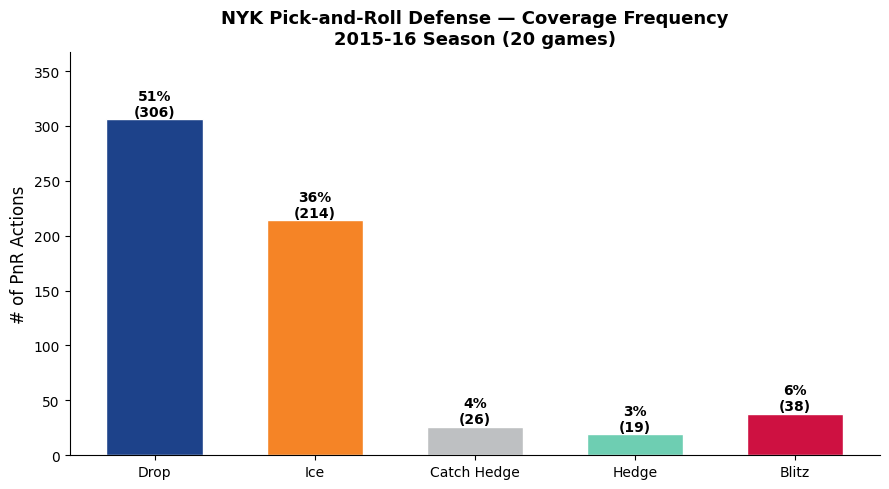

In [25]:
COVERAGE_COLORS = {
    'Drop': '#1d428a', 'Ice': '#f58426',
    'Hedge': '#6eceb2', 'Blitz': '#ce1141', 'Catch Hedge': '#bec0c2'
}
ORDER = ['Drop', 'Ice', 'Catch Hedge', 'Hedge', 'Blitz']

counts = pnr_df['coverage'].value_counts().reindex(ORDER).fillna(0)
pcts   = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index,
              counts.values,
              color=[COVERAGE_COLORS[c] for c in counts.index],
              edgecolor='white', width=0.6)
for bar, pct, cnt in zip(bars, pcts, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.0f}%\n({int(cnt)})', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('# of PnR Actions', fontsize=12)
ax.set_title('NYK Pick-and-Roll Defense — Coverage Frequency\n2015-16 Season (20 games)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### What outcomes does each coverage produce?

We link each screen to the next shot, turnover, or foul within 14 seconds using the play-by-play data.

Coverage Effectiveness (shots + turnovers only):
             plays  fg_pct    ppp
coverage                         
Drop           189   0.365  0.730
Ice            157   0.401  0.803
Catch Hedge     14   0.357  0.714
Hedge           16   0.438  0.875
Blitz           26   0.269  0.538


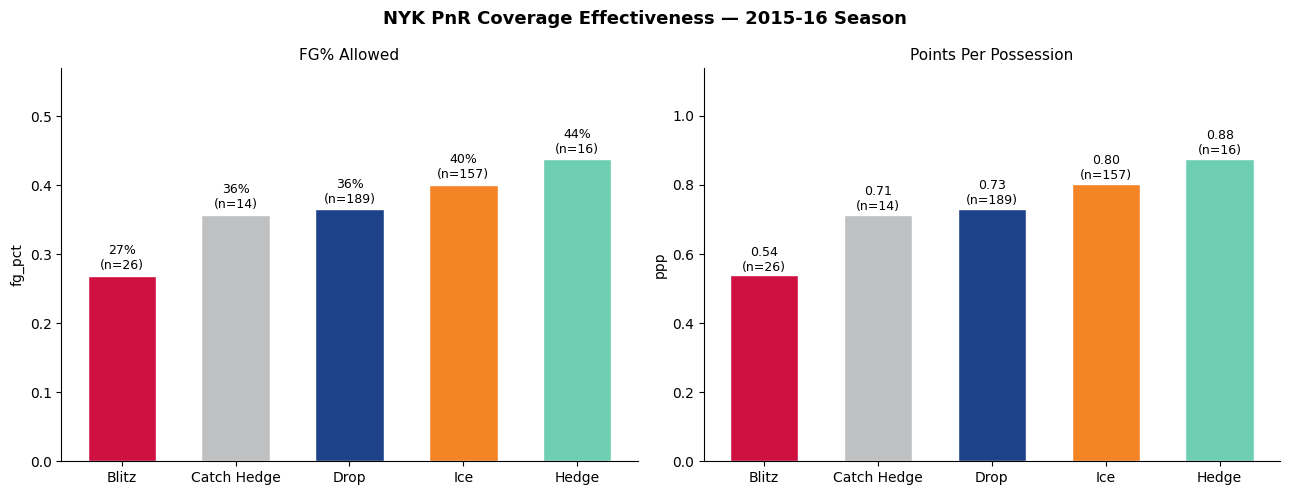

In [26]:
shot_df = pnr_df[pnr_df['outcome'].isin(['Made FG', 'Missed FG', 'Turnover'])].copy()
shot_df['pts'] = shot_df['outcome'].map({'Made FG': 2, 'Missed FG': 0, 'Turnover': 0})
shot_df['made'] = (shot_df['outcome'] == 'Made FG').astype(int)

by_cov = (
    shot_df.groupby('coverage')
    .agg(plays=('pts','count'), fg_pct=('made','mean'), ppp=('pts','mean'))
    .round(3)
    .reindex(ORDER).dropna()
)

print('Coverage Effectiveness (shots + turnovers only):')
print(by_cov.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('NYK PnR Coverage Effectiveness — 2015-16 Season',
             fontsize=13, fontweight='bold')

for ax, col, title, fmt in [
    (axes[0], 'fg_pct', 'FG% Allowed',            '{:.0%}'),
    (axes[1], 'ppp',    'Points Per Possession',   '{:.2f}'),
]:
    vals = by_cov[col].sort_values()
    colors = [COVERAGE_COLORS.get(c, 'gray') for c in vals.index]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', width=0.6)
    for bar, val, n in zip(bars, vals.values, by_cov.loc[vals.index, 'plays']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{fmt.format(val)}\n(n={int(n)})', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(col)
    ax.set_ylim(0, vals.max() * 1.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

### Outcome breakdown by coverage type

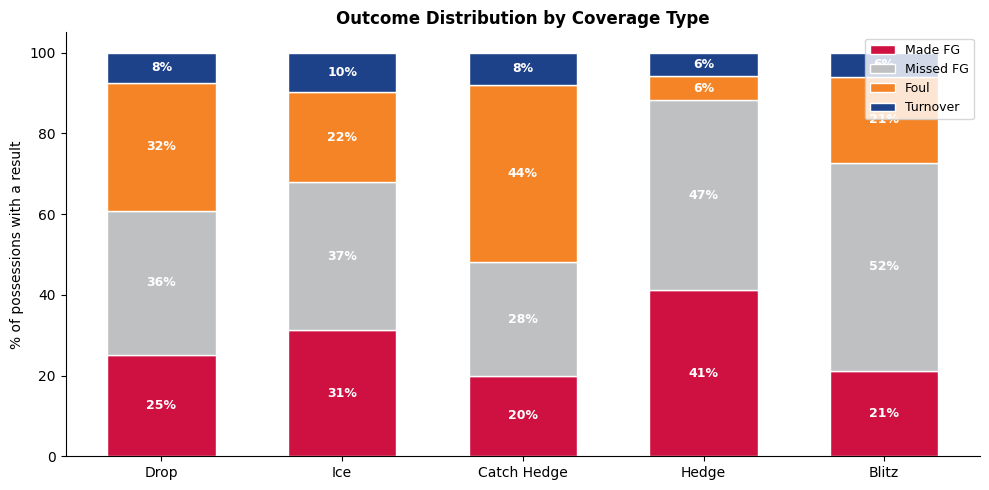

In [27]:
outcome_breakdown = (
    pnr_df[pnr_df['outcome'] != 'No Result']
    .groupby(['coverage','outcome'])
    .size().unstack(fill_value=0)
)
# Normalize to percentages
outcome_pct = outcome_breakdown.div(outcome_breakdown.sum(axis=1), axis=0) * 100
outcome_pct = outcome_pct.reindex(ORDER).dropna()

outcome_colors = {'Made FG':'#ce1141','Missed FG':'#bec0c2','Foul':'#f58426','Turnover':'#1d428a'}

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(outcome_pct))
for outcome in ['Made FG','Missed FG','Foul','Turnover']:
    if outcome not in outcome_pct.columns:
        continue
    vals = outcome_pct[outcome].values
    bars = ax.bar(outcome_pct.index, vals, bottom=bottom,
                  color=outcome_colors.get(outcome,'gray'),
                  label=outcome, edgecolor='white', width=0.6)
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('% of possessions with a result')
ax.set_title('Outcome Distribution by Coverage Type', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## Step 4 — Example: One Real PnR

A court visualization of one detected PnR screen — the 4 key players' movement trails over the 3-second window after the screen.

Showing a Drop coverage example:
  Ball handler:  Jimmy Butler
  Screener:      Nikola Mirotic
  Outcome:       Missed FG


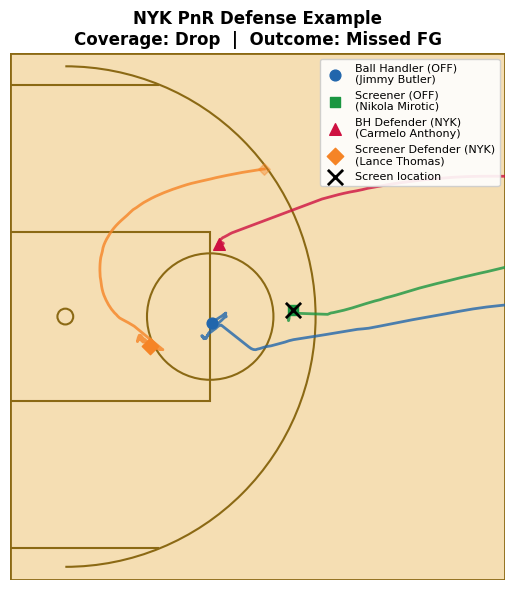

In [28]:
def draw_half_court(ax, side='left'):
    x0 = 0 if side == 'left' else 47
    bx = 5.25 if side == 'left' else 88.75
    d  = 1 if side == 'left' else -1
    ax.set_facecolor('#f5deb3')
    ax.add_patch(patches.Rectangle((x0,0), 47, 50, lw=2, edgecolor='#8B6914', facecolor='#f5deb3'))
    ax.add_patch(patches.Rectangle((x0,17), 19, 16, lw=1.5, edgecolor='#8B6914', facecolor='none'))
    ax.add_patch(patches.Circle((bx,25), 0.75, color='#8B6914', lw=1.5, fill=False))
    ax.add_patch(patches.Arc((bx,25), 47.5, 47.5, angle=0,
                              theta1=(-90 if side=='left' else 90),
                              theta2=(90 if side=='left' else 270),
                              color='#8B6914', lw=1.5))
    cx = 0 if side=='left' else 94
    ax.plot([cx, cx+d*14],[3,3],  color='#8B6914', lw=1.5)
    ax.plot([cx, cx+d*14],[47,47],color='#8B6914', lw=1.5)
    ftx = 19 if side=='left' else 75
    ax.add_patch(patches.Circle((ftx,25), 6, color='#8B6914', lw=1.5, fill=False))
    ax.set_xlim(x0, x0+47); ax.set_ylim(0,50)
    ax.set_aspect('equal'); ax.axis('off')


def plot_pnr_example(screen, all_game_results, n=0):
    """
    Re-extract the raw tracking data for the given screen and plot player paths.
    We need to re-open the archive for this — pull from the first available game.
    """
    game_id  = screen['game_id']
    eid      = screen['event_id']
    q        = screen['quarter']
    t0       = screen['game_clock']
    scr_x    = screen['screen_x']
    side     = 'left' if scr_x < 47 else 'right'

    # Try to find and re-extract the relevant archive
    archive = None
    for f in NYK_ARCHIVES:
        if os.path.basename(f)[:10].replace('.','') in game_id.replace('002150',''):
            archive = f
            break
    # Fallback: just use first archive
    if archive is None:
        archive = NYK_ARCHIVES[0]

    with tempfile.TemporaryDirectory() as tmpdir:
        subprocess.run(['7z','e', archive, f'-o{tmpdir}','-y'], capture_output=True)
        jfiles = glob.glob(os.path.join(tmpdir,'*.json'))
        if not jfiles:
            print('Could not extract game data for visualization.')
            return
        with open(jfiles[0]) as f:
            game = json.load(f)

    game_id_file = game.get('gameid','')
    if game_id_file != game_id:
        print(f'Game ID mismatch ({game_id_file} vs {game_id}) — skipping viz.')
        return

    ev0 = game['events'][0]
    home = ev0['home']; visitor = ev0['visitor']
    all_names = {p['playerid']: f"{p['firstname']} {p['lastname']}"
                 for p in home['players'] + visitor['players']}
    all_names[-1] = 'ball'

    rows = []
    for event in game['events']:
        if event['eventId'] != eid: continue
        for moment in event['moments']:
            mq, _, gc, _ = moment[0], moment[1], moment[2], moment[3]
            if mq != q: continue
            for player in moment[5]:
                rows.append({'player_id': player[1], 'x': player[2],
                             'y': player[3], 'game_clock': gc})
    if not rows:
        print('No moment data found for this screen.')
        return

    mdf = pd.DataFrame(rows)
    window = mdf[(mdf['game_clock'] <= t0) & (mdf['game_clock'] >= t0 - 3.0)]

    fig, ax = plt.subplots(figsize=(10, 6))
    draw_half_court(ax, side=side)

    player_styles = {
        screen['bh_id']:          ('Ball Handler (OFF)',     '#2166ac', 'o', 60),
        screen['screener_id']:    ('Screener (OFF)',         '#1a9641', 's', 60),
        screen['bh_def_id']:      ('BH Defender (NYK)',      '#ce1141', '^', 70),
        screen['screener_def_id']:('Screener Defender (NYK)','#f58426', 'D', 70),
    }

    for pid, (label, color, marker, ms) in player_styles.items():
        ptrack = window[window['player_id'] == pid].sort_values('game_clock', ascending=False)
        if ptrack.empty: continue
        ax.plot(ptrack['x'], ptrack['y'], color=color, lw=2, alpha=0.8)
        ax.scatter(ptrack.iloc[0]['x'], ptrack.iloc[0]['y'],
                   color=color, marker=marker, s=ms, zorder=5,
                   label=f"{label}\n({all_names.get(pid, pid)})")
        ax.scatter(ptrack.iloc[-1]['x'], ptrack.iloc[-1]['y'],
                   color=color, marker=marker, s=ms*0.5, alpha=0.4, zorder=5)

    ax.scatter(screen['screen_x'], screen['screen_y'],
               marker='x', s=120, color='black', zorder=6, linewidths=2, label='Screen location')

    coverage = screen.get('coverage', '?')
    outcome  = screen.get('outcome', '?')
    ax.set_title(f'NYK PnR Defense Example\nCoverage: {coverage}  |  Outcome: {outcome}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    plt.tight_layout()
    plt.show()


# Plot an example from the most common coverage type
most_common = pnr_df['coverage'].value_counts().index[0]
example = pnr_df[
    (pnr_df['coverage'] == most_common) &
    (pnr_df['outcome'].isin(['Made FG','Missed FG']))
].iloc[0]

print(f'Showing a {most_common} coverage example:')
print(f'  Ball handler:  {example["bh_name"]}')
print(f'  Screener:      {example["scr_name"]}')
print(f'  Outcome:       {example["outcome"]}')
plot_pnr_example(example, all_results)

## Summary

This notebook demonstrates the full pipeline for analyzing NBA pick-and-roll defense from raw tracking data:

1. **Screen detection** from player position + velocity (no manual tagging)
2. **Coverage classification** using positional rules derived from how each defender moves relative to the screen
3. **Outcome attachment** via play-by-play join

The results show NYK's defensive tendencies across 20 games and which coverages gave up the most/fewest points.

*Data: NBA SportVU 2015-16, NYK first 20 games in dataset.*